# Transfer Learning CIFAR10

* Train a simple convnet on the CIFAR dataset the first 5 output classes [0..4].
* Freeze convolutional layers and fine-tune dense layers for the last 5 ouput classes [5..9].


### 1. Import CIFAR10 data and create 2 datasets with one dataset having classes from 0 to 4 and other having classes from 5 to 9 

In [0]:
# Initialize the random number generator
import random
random.seed(7)

import warnings
warnings.filterwarnings("ignore")

In [6]:
from keras.backend import backend
from keras.datasets import cifar10

# the data, shuffled and split between train and test sets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

Using TensorFlow backend.


170500096/170498071 [==============================] - 2s 0us/step


In [7]:
# print the data-shape
print (X_train.shape,  y_train.shape)
print (X_test.shape,  y_test.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [0]:
y_train = y_train.reshape(y_train.shape[0],)
y_test = y_test.reshape(y_test.shape[0],)

In [9]:
# print y after reshape
print (y_train.shape, y_test.shape) 

(50000,) (10000,)


In [0]:
import numpy as np

train_mask1 = np.isin(y_train, [0, 1, 2, 3, 4])
test_mask1 = np.isin(y_test, [0, 1, 2, 3, 4])

train_mask2 = np.isin(y_train, [5, 6, 7, 8, 9])
test_mask2 = np.isin(y_test, [5, 6, 7, 8, 9])

In [0]:
# Train and Test DataSet with 0 to 4 digits
X_train1, y_train1 = X_train[train_mask1], y_train[train_mask1]
X_test1, y_test1 = X_test[test_mask1 ], y_test[test_mask1 ]

# Train and Test DataSet with 5 to 9 digits
X_train2, y_train2 = X_train[train_mask2], y_train[train_mask2]
X_test2, y_test2 = X_test[test_mask2], y_test[test_mask2]

In [12]:
np.unique(y_test1)

array([0, 1, 2, 3, 4])

In [13]:
np.unique(y_test2)

array([5, 6, 7, 8, 9])

In [14]:
# Dataset-1 for 0-4 labels
print (X_train1.shape,  y_train1.shape)
print (X_test1.shape,  y_test1.shape)

(25000, 32, 32, 3) (25000,)
(5000, 32, 32, 3) (5000,)


In [15]:
# Dataset-2 for 5-9 labels
print (X_train2.shape,  y_train2.shape)
print (X_test2.shape,  y_test2.shape)

(25000, 32, 32, 3) (25000,)
(5000, 32, 32, 3) (5000,)


In [0]:
#Normalize the data
X_train1= X_train1.astype('float32')
X_train1/=255

X_test1= X_test1.astype('float32')
X_test1/=255

In [17]:
print ("Num of Images in X_train =", X_train1.shape[0])
print ("Num of Images in X_test =", X_test1.shape[0])

Num of Images in X_train = 25000
Num of Images in X_test = 5000


### 2. Use One-hot encoding to divide y_train and y_test into required no of output classes

In [0]:
import keras

In [0]:
#Encoding the output class label (One-Hot Encoding)
y_train1= keras.utils.to_categorical(y_train1)
y_test1 = keras.utils.to_categorical(y_test1)

In [20]:
print (y_train1.shape, y_test1.shape)

(25000, 5) (5000, 5)


### 3. Build a sequential neural network model which can classify the classes 0 to 4 of CIFAR10 dataset with at least 80% accuracy on test data

In [0]:
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import optimizers
import sys
from matplotlib import pyplot

In [0]:
def define_model():
	model = Sequential()
	model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(32, 32, 3)))
	model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
	model.add(MaxPooling2D((2, 2)))
	model.add(Dropout(0.2))
	model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
	model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
	model.add(MaxPooling2D((2, 2)))
	model.add(Dropout(0.2))
	model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
	model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
	model.add(MaxPooling2D((2, 2)))
	model.add(Dropout(0.2))
	model.add(Flatten())
	model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
	model.add(Dropout(0.2))
	model.add(Dense(5, activation='softmax'))
	# compile model
	opt = optimizers.SGD(lr=0.001, momentum=0.9)
	model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
	return model

In [0]:
# plot diagnostic learning curves
def cross_entropy_plot(history):
	# plot loss
	pyplot.subplot(211)
	pyplot.title('Cross Entropy Loss')
	pyplot.plot(history.history['loss'], color='blue', label='train')
	pyplot.plot(history.history['val_loss'], color='orange', label='test')

def classification_acc_plot(history):
	# plot accuracy
	pyplot.subplot(212)
	pyplot.title('Classification Accuracy')
	pyplot.plot(history.history['acc'], color='blue', label='train')
	pyplot.plot(history.history['val_acc'], color='orange', label='test')

In [24]:
# define model
model = define_model()

#summary 
model.summary()






Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 32, 32, 32)        896       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 32, 32, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 16, 16, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 16, 16, 32)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 16, 16, 64)        18496     
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 16, 16, 64)        36928    

In [25]:
# fit model
history = model.fit(X_train1, y_train1, batch_size=64, nb_epoch=35, verbose=1, validation_data=(X_test1,y_test1))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Train on 25000 samples, validate on 5000 samples
Epoch 1/35
25000/25000 [==============================] - 18s 739us/step - loss: 1.4159 - acc: 0.3890 - val_loss: 1.2578 - val_acc: 0.4510
Epoch 2/35
25000/25000 [==============================] - 11s 444us/step - loss: 1.1251 - acc: 0.5326 - val_loss: 1.0039 - val_acc: 0.5830
Epoch 3/35
25000/25000 [==============================] - 11s 443us/step - loss: 1.0351 - acc: 0.5747 - val_loss: 0.9458 - val_acc: 0.6154
Epoch 4/35
25000/25000 [==============================] - 11s 433us/step - loss: 0.9735 - acc: 0.6038 - val_loss: 0.8945 - val_acc: 0.6408
Epoch 5/35
25000/25000 [==============================] - 11s 433us/step - loss: 0.9324 - acc: 0.6241 - val_loss: 0.8946 - val_acc: 0.6414
Epoch 6/35
25000/25000 [==============================] - 11s 439us/step - loss: 0.9096 - acc: 0.6336 - val_loss: 0.8349 - val_acc: 0.6486
Epoch 7/35
25000/25000 

In [26]:
_, acc_score = model.evaluate(X_test1, y_test1, verbose=0)
print('Test Accuracy  %.3f' % (acc_score * 100.0))

Test Accuracy  82.440


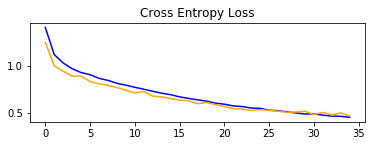

In [27]:
# learning curves
cross_entropy_plot(history)

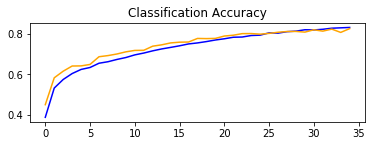

In [28]:
# learning curves
classification_acc_plot(history)

### 4. In the model which was built above (for classification of classes 0-4 in CIFAR10), make only the dense layers to be trainable and conv layers to be non-trainable

In [29]:
#Set pre-trained model layers to not trainable (except for Dense layers)
for layer in model.layers:
  str_sub = str(layer)
  if (str_sub.find('core.Dense') == -1):
    print (str_sub)
    layer.trainable = False

### 5. Utilize the the model trained on CIFAR 10 (classes 0 to 4) to classify the classes 5 to 9 of CIFAR 10  (Use Transfer Learning) <br>
Achieve an accuracy of more than 85% on test data

In [30]:
y_train2-=5
y_test2-=5
print(y_train2, y_test2)

[1 4 4 ... 0 1 4] [3 3 1 ... 3 0 2]


In [0]:
X_train2= X_train2.astype('float32')
X_train2/=255

X_test2= X_test2.astype('float32')
X_test2/=255

In [32]:
print ("Num of Images in X_train =", X_train2.shape[0])
print ("Num of Images in X_test =", X_test2.shape[0])

Num of Images in X_train = 25000
Num of Images in X_test = 5000


In [33]:
#Encoding the output class label (One-Hot Encoding)
y_train2= keras.utils.to_categorical(y_train2)
y_test2 = keras.utils.to_categorical(y_test2)
print (y_train2.shape, y_test2.shape)

(25000, 5) (5000, 5)


In [34]:
# fit the model
history2 = model.fit(X_train2, y_train2, batch_size=64, nb_epoch=20, verbose=1, validation_data=(X_test2,y_test2))

Train on 25000 samples, validate on 5000 samples
Epoch 1/20
25000/25000 [==============================] - 11s 449us/step - loss: 1.0125 - acc: 0.6111 - val_loss: 0.6113 - val_acc: 0.7716
Epoch 2/20
25000/25000 [==============================] - 10s 408us/step - loss: 0.6563 - acc: 0.7573 - val_loss: 0.5821 - val_acc: 0.7760
Epoch 3/20
25000/25000 [==============================] - 10s 400us/step - loss: 0.5827 - acc: 0.7872 - val_loss: 0.4762 - val_acc: 0.8246
Epoch 4/20
25000/25000 [==============================] - 9s 376us/step - loss: 0.5259 - acc: 0.8074 - val_loss: 0.4279 - val_acc: 0.8438
Epoch 5/20
25000/25000 [==============================] - 10s 384us/step - loss: 0.4836 - acc: 0.8233 - val_loss: 0.4495 - val_acc: 0.8350
Epoch 6/20
25000/25000 [==============================] - 10s 383us/step - loss: 0.4576 - acc: 0.8330 - val_loss: 0.3768 - val_acc: 0.8654
Epoch 7/20
25000/25000 [==============================] - 10s 382us/step - loss: 0.4430 - acc: 0.8401 - val_loss: 0.36

In [35]:
_, acc_score2 = model.evaluate(X_test2, y_test2, verbose=0)
print('Test Accuracy using Transfer Learning %.3f' % (acc_score2 * 100.0))

Test Accuracy using Transfer Learning 90.680


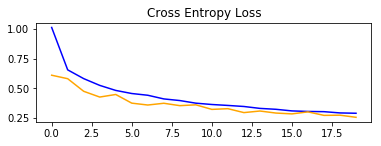

In [36]:
# learning curves
cross_entropy_plot(history2)

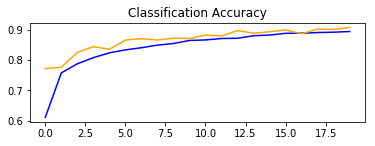

In [37]:
# learning curves
classification_acc_plot(history2)

# Text classification using TF-IDF

### 6. Load the dataset from sklearn.datasets

In [0]:
from sklearn.datasets import fetch_20newsgroups

In [0]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

### 7. Training data

In [0]:
twenty_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42, remove=('headers', 'footers', 'quotes'))

### 8. Test data

In [0]:
twenty_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42, remove=('headers', 'footers', 'quotes'))

###  a.  You can access the values for the target variable using .target attribute 
###  b. You can access the name of the class in the target variable with .target_names


In [7]:
twenty_train.target

array([1, 1, 3, ..., 2, 2, 2])

In [8]:
twenty_train.target_names

['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

In [9]:
twenty_train.data[0:5]

['Does anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.',
 "Hi,\n\n\tI have a problem, I hope some of the 'gurus' can help me solve.\n\n\tBackground of the problem:\n\tI have a rectangular mesh in the uv domain, i.e  the mesh is a \n\tmapping of a 3d Bezier patch into 2d. The area in this domain\n\twhich is inside a trimming loop had to be rendered. The trimming\n\tloop is a set of 2d Bezier curve segments.\n\tFor the sake of notation: the mesh is made up of cells.\n\n\tMy problem is this :\n\tThe trimming area has to be split up into individual smaller\n\tcells bounded by the trimming curve segments. If a cell\n\tis wholly inside the area...then it is output as a whole ,\n\telse it is trivially rejected. \n\n\tDoes any body know how thiss can be done,

### 9.  Now with dependent and independent data available for both train and test datasets, using TfidfVectorizer fit and transform the training data and test data and get the tfidf features for both

In [0]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [0]:
tfvc = TfidfVectorizer(lowercase=True, analyzer='word',
                        stop_words= 'english',ngram_range=(1,3),dtype=np.float32)

train_data_features= tfvc.fit(twenty_train.data)
tfvc_data= tfvc.transform(twenty_train.data)

df= pd.DataFrame(tfvc_data.todense(),columns=tfvc.get_feature_names())

### 10. Use logisticRegression with tfidf features as input and targets as output and train the model and report the train and test accuracy score

In [12]:
from sklearn.linear_model import LogisticRegression 
X_train = df 
y_train = twenty_train.target

model = LogisticRegression()
log_model = model.fit(X_train, y_train)

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:469: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)


In [13]:
train_acc = log_model.score(X_train,y_train)
print ("Train-Accuracy =", train_acc)

Train-Accuracy = 0.9778466991581746


In [14]:
X_test = tfvc .transform(twenty_test.data)
y_test = twenty_test.target
test_acc = log_model.score(X_test,y_test)
print ("Test-Accuracy =", test_acc)

Test-Accuracy = 0.7909454061251664
